In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




1

In [9]:
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.flatten() + 1.5
y_test = pd.read_csv('y_test.csv').values.flatten() + 1.5

read data successful

In [10]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                   solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
residuals = y_test - y_pred

the closer R² is to 1, the better.
MSE/MAE: Measures the magnitude of the average error. The smaller the value, the more accurate it is.
Residuals: Represents the "how much the prediction deviates from the actual value" for each sample

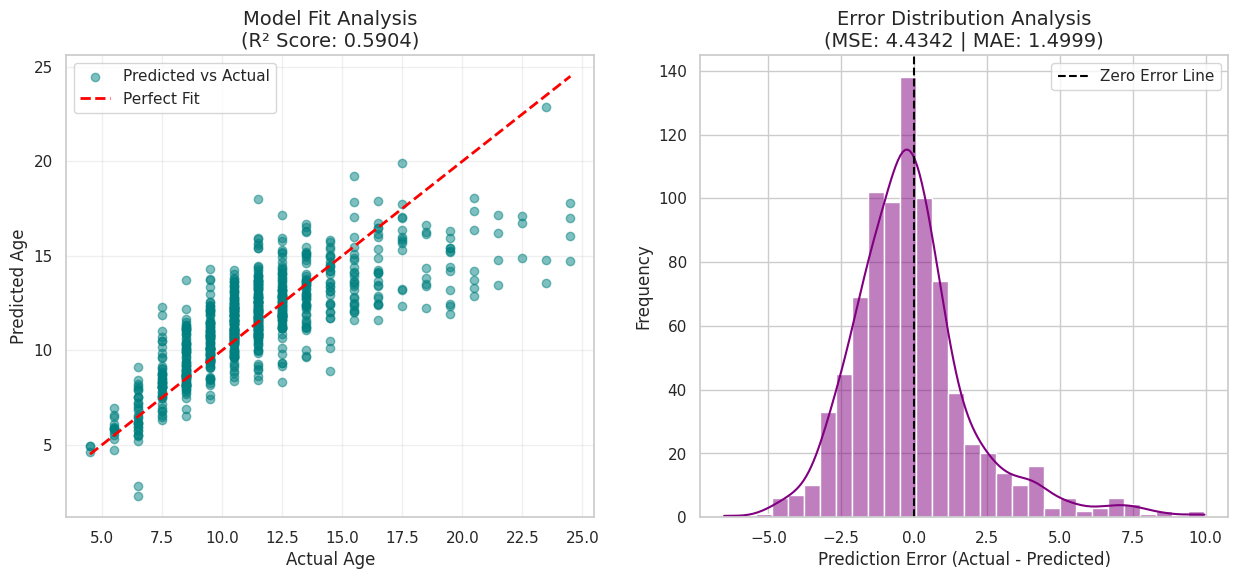

In [11]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Predicted vs Actual')
line_coords = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.title(f'Model Fit Analysis\n(R² Score: {r2:.4f})', fontsize=14)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(0, color='black', linestyle='--', label='Zero Error Line')
plt.title(f'Error Distribution Analysis\n(MSE: {mse:.4f} | MAE: {mae:.4f})', fontsize=14)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()

In [12]:
mask_train_f = (X_train['Sex_F'] == True) | (X_train['Sex_F'] == 1)
mask_train_i = (X_train['Sex_I'] == True) | (X_train['Sex_I'] == 1)
mask_train_m = (X_train['Sex_M'] == True) | (X_train['Sex_M'] == 1)

mask_test_f = (X_test['Sex_F'] == True) | (X_test['Sex_F'] == 1)
mask_test_i = (X_test['Sex_I'] == True) | (X_test['Sex_I'] == 1)
mask_test_m = (X_test['Sex_M'] == True) | (X_test['Sex_M'] == 1)

#Based on gender characteristics, classify the local independent data sets

In [13]:
mlp_global = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp_global.fit(X_train, y_train)

y_pred_global_f = mlp_global.predict(X_test[mask_test_f])
y_pred_global_i = mlp_global.predict(X_test[mask_test_i])
y_pred_global_m = mlp_global.predict(X_test[mask_test_m])

#Train the Global overall model


             Global vs Local
     Group Model_Type      MSE      MAE       R2
Female (F)     Global 6.138896 1.832491 0.424395
Female (F)      Local 6.217243 1.814441 0.417049
Infant (I)     Global 2.014839 1.035032 0.556403
Infant (I)      Local 2.151875 1.082831 0.526232
  Male (M)     Global 5.083403 1.620404 0.441801
  Male (M)      Local 5.226237 1.650314 0.426117



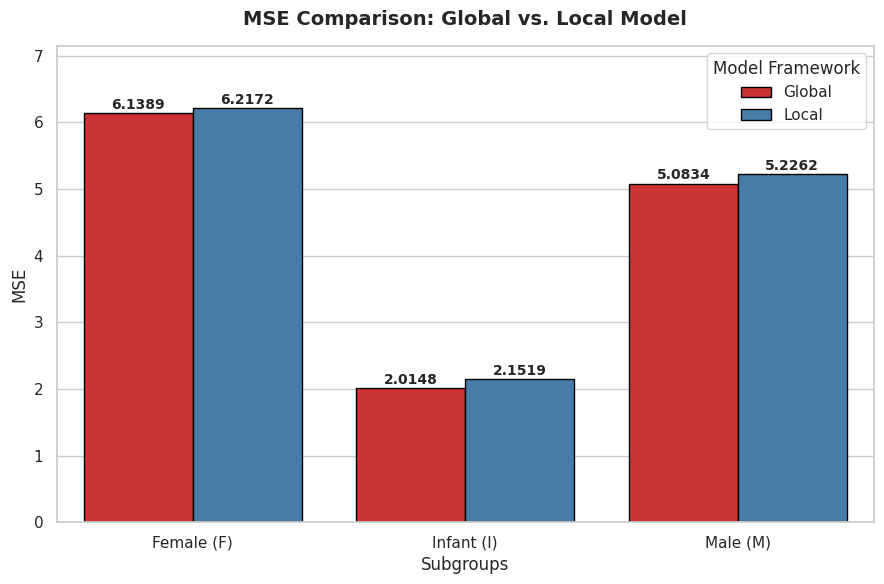

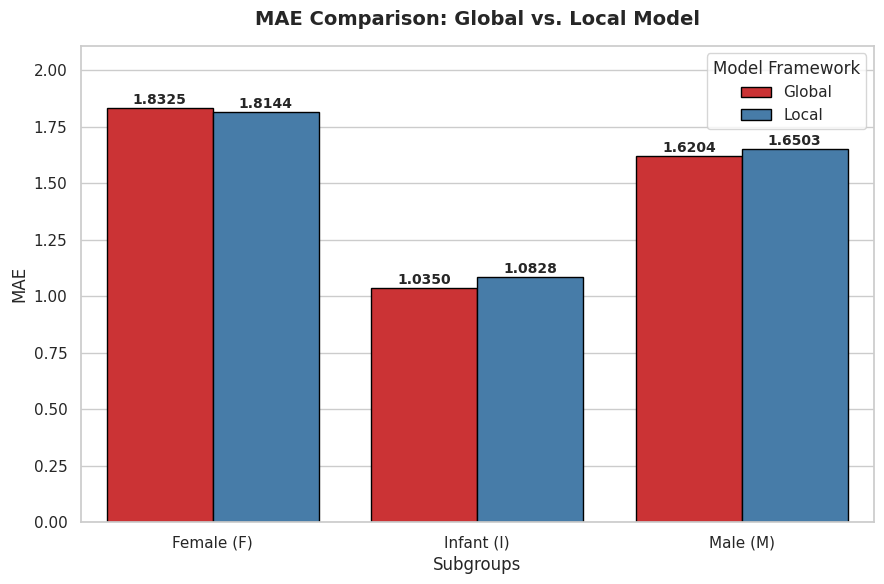

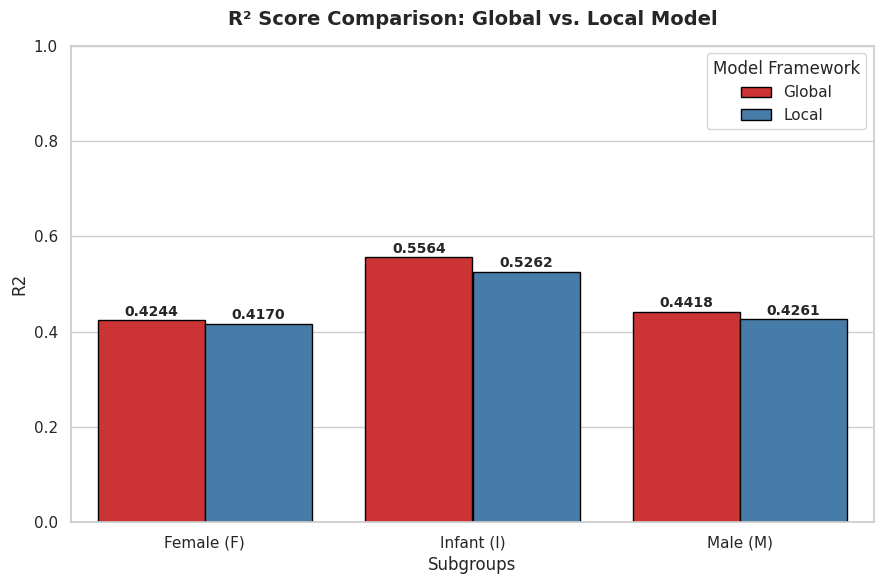

In [14]:
# (1) Female Model
mlp_local_f = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp_local_f.fit(X_train[mask_train_f], y_train[mask_train_f])
y_pred_local_f = mlp_local_f.predict(X_test[mask_test_f])

# (2) Infant Model
mlp_local_i = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp_local_i.fit(X_train[mask_train_i], y_train[mask_train_i])
y_pred_local_i = mlp_local_i.predict(X_test[mask_test_i])

# (3) Male Model
mlp_local_m = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp_local_m.fit(X_train[mask_train_m], y_train[mask_train_m])
y_pred_local_m = mlp_local_m.predict(X_test[mask_test_m])

results = [
    ['Female (F)', 'Global', mean_squared_error(y_test[mask_test_f], y_pred_global_f), mean_absolute_error(y_test[mask_test_f], y_pred_global_f), r2_score(y_test[mask_test_f], y_pred_global_f)],
    ['Female (F)', 'Local', mean_squared_error(y_test[mask_test_f], y_pred_local_f), mean_absolute_error(y_test[mask_test_f], y_pred_local_f), r2_score(y_test[mask_test_f], y_pred_local_f)],

    ['Infant (I)', 'Global', mean_squared_error(y_test[mask_test_i], y_pred_global_i), mean_absolute_error(y_test[mask_test_i], y_pred_global_i), r2_score(y_test[mask_test_i], y_pred_global_i)],
    ['Infant (I)', 'Local', mean_squared_error(y_test[mask_test_i], y_pred_local_i), mean_absolute_error(y_test[mask_test_i], y_pred_local_i), r2_score(y_test[mask_test_i], y_pred_local_i)],

    ['Male (M)', 'Global', mean_squared_error(y_test[mask_test_m], y_pred_global_m), mean_absolute_error(y_test[mask_test_m], y_pred_global_m), r2_score(y_test[mask_test_m], y_pred_global_m)],
    ['Male (M)', 'Local', mean_squared_error(y_test[mask_test_m], y_pred_local_m), mean_absolute_error(y_test[mask_test_m], y_pred_local_m), r2_score(y_test[mask_test_m], y_pred_local_m)]
]

df_results = pd.DataFrame(results, columns=['Group', 'Model_Type', 'MSE', 'MAE', 'R2'])

print("\n" + "="*60)
print("             Global vs Local")
print("="*60)
print(df_results.to_string(index=False))
print("="*60 + "\n")

sns.set_theme(style="whitegrid")
metrics = ['MSE', 'MAE', 'R2']
titles = ['MSE Comparison: Global vs. Local Model',
          'MAE Comparison: Global vs. Local Model',
          'R² Score Comparison: Global vs. Local Model']

for metric, title in zip(metrics, titles):
    plt.figure(figsize=(9, 6))

    ax = sns.barplot(
        data=df_results,
        x='Group',
        y=metric,
        hue='Model_Type',
        palette='Set1',
        edgecolor='black',
        linewidth=1
    )

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.4f}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 6),
                        textcoords='offset points',
                        fontsize=10, fontweight='bold')

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Subgroups', fontsize=12)
    plt.ylabel(metric, fontsize=12)

    if metric == 'R2':
        plt.ylim(0, 1.0)
    else:
        plt.ylim(0, df_results[metric].max() * 1.15)

    plt.legend(title='Model Framework')
    plt.tight_layout()

    filename = f'MLP_Comparison_{metric}.png'
    plt.savefig(filename, dpi=300)
    plt.show()